In [1]:
from microspike import PatternGenerator, SRMInhibitory, InputTrain, Synapse, Monitor, Network
from microspike.utils import model_config, synapse_config, investigate_potential
from collections import defaultdict
import numpy as np
import os
from microspike.utils import w_uniform
import matplotlib.pyplot as plt

In [2]:
dt = 0.001

def get_latency_results(N, monitor, position_copypaste, start_inference_time,  patternlength=0.050):
    result = defaultdict(list)
    idx = np.where(monitor.spikes_t > start_inference_time)[0]
    t = monitor.spikes_t[idx]
    i = monitor.spikes_i[idx]

    for spike_t, spike_i in zip(t, i):
        position_idx = int(spike_t / patternlength)
        pattern_number = position_copypaste[position_idx]
        latency = np.round(spike_t - position_idx * patternlength, decimals=3) * 1000
        if spike_i < N:
            result[f"pattern_{pattern_number}_original_neuron"].append(latency.item())
        else:
            result[f"pattern_{pattern_number}_new_neuron"].append(latency.item())

    return result


def plot_new_pattern_hist(P, result, display:bool, result_dir, image_name):
    fig, axs = plt.subplots(P + 1, 1, figsize=(6, 6))
    for i in range(P + 1):
        axs[i].grid(True)
        axs[i].set_xlim([0, 50])
        # Set x-axis ticks to all integers from 0 to 50
        axs[i].set_xticks(np.arange(0, 51, 5))  # Adjust step size as needed

        axs[i].hist(result[f"pattern_{i+1}_original_neuron"], alpha=0.5, label="Original Neuron", bins=3)
        axs[i].hist(result[f"pattern_{i+1}_new_neuron"], alpha=0.5, label="New Neuron", bins=3)
        axs[i].set_title(f"Pattern {i+1}")
        axs[i].set_xlabel("Latency (ms)")
        axs[i].set_ylabel("Frequency")
        axs[i].legend()
        


    plt.tight_layout()
    
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
    plt.savefig(os.path.join(result_dir, image_name))

    if display:
        plt.show()

In [3]:
P = 1
N = 1
num_new_neurons = 1
M = 2000
time = 200 * 1000
start_inference_time = 150
display = True
result_dir = 'tmpdir'
image_name = "sample_run.png" # 'P1N1_P2N2.png'

In [4]:
generator = PatternGenerator(number_pattern=P, number_neurons=M,
                                total_pattern_freq = 1/3,
                                )
times, indices, position_copypaste, patterns_info, timing_pattern = generator.generate()

weight = w_uniform(M=M, N=N)

In [5]:
input_train = InputTrain(times, indices)

model = SRMInhibitory(N=N,
            **model_config
            )
synapse = Synapse(w=weight,
                  use_punishment_interface=True,
                **synapse_config
                )

monitor = Monitor(model)
net = Network(dt=dt)

net.add_input_train(input_train)
net.add_layer(model)
net.add_synapse(synapse)

net.run(time= time)

TypeError: Synapse.__init__() got an unexpected keyword argument 'use_punishment_interface'

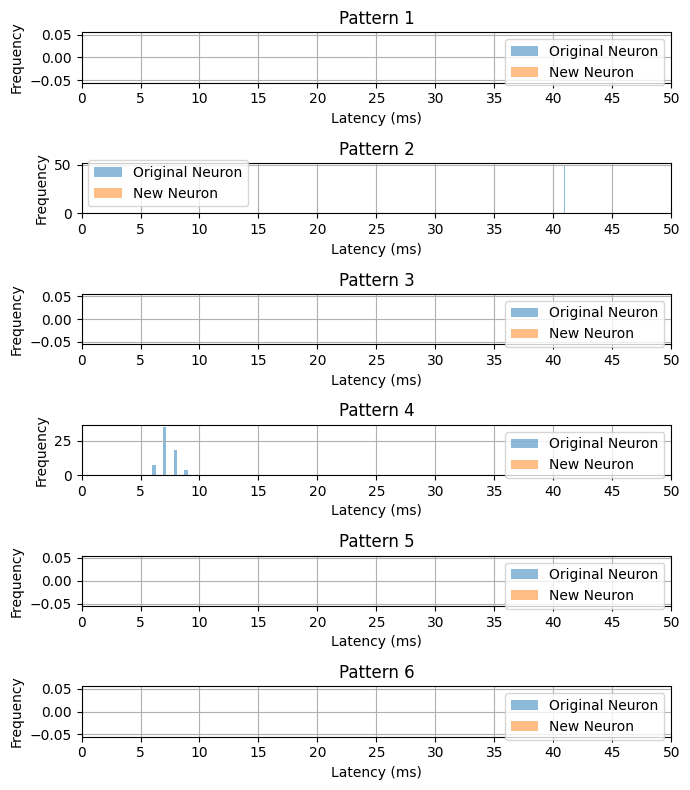

In [7]:
result = get_latency_results(N, monitor, position_copypaste, start_inference_time, patternlength=0.050)

plot_new_pattern_hist(P, result, display, result_dir, image_name[:-4] + "_only_originals.png")

In [7]:
times_added, indices_added, position_copypaste_added, patterns_info_added = generator.add_new_pattern(times, indices, position_copypaste, patterns_info)

input_train = InputTrain(times_added, indices_added, position_copypaste_added)
model.add_new_neurons(num_new_neurons=num_new_neurons)
synapse.add_new_neurons(num_new_neurons=num_new_neurons)

monitor = Monitor(model)

net = Network(dt=dt)
net.add_new_neurons(num_original_patterns= P)

net.add_input_train(input_train)
net.add_layer(model)
net.add_synapse(synapse)

net.run(time= time)

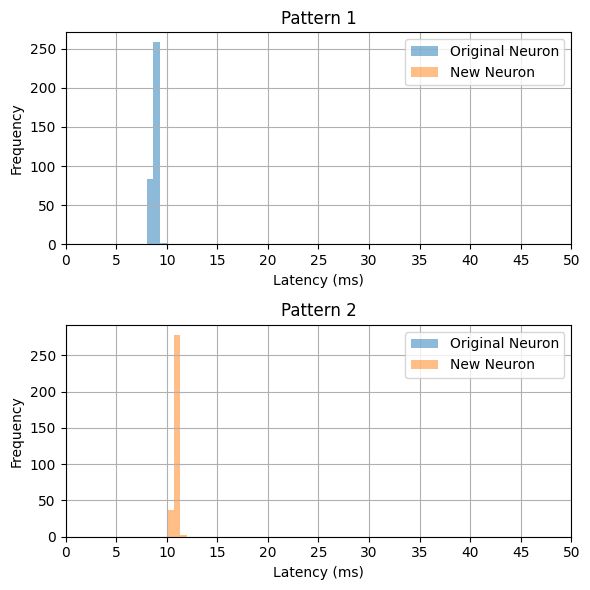

In [8]:
result = get_latency_results(N, monitor, position_copypaste_added, start_inference_time,  patternlength=0.050)

plot_new_pattern_hist(P, result, display, result_dir, image_name)

In [9]:
investigate_potential(monitor=monitor, dt=dt, position_copypaste=position_copypaste_added)

## Only eeward, 3 new neurons 

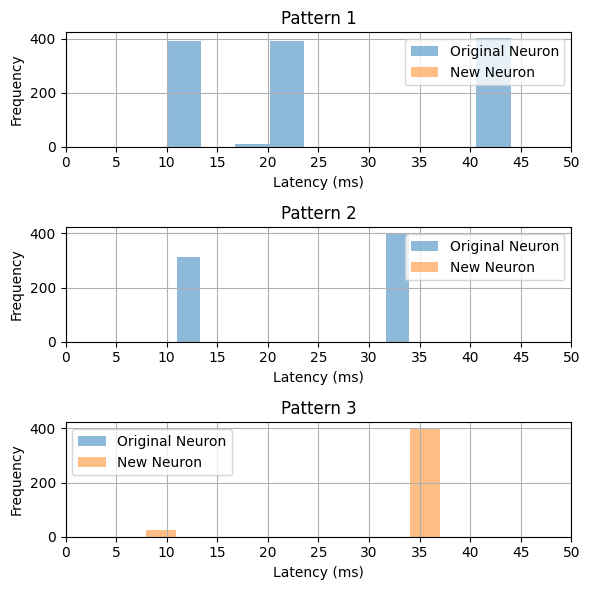

In [8]:
result = get_latency_results(N, monitor, position_copypaste_added, patternlength=0.050)

plot_new_pattern_hist(P, result, display, result_dir, image_name)

In [10]:
set(result["pattern_3_new_neuron"])

{8.0, 9.0, 10.0, 36.0, 37.0}

In [12]:
from copy import deepcopy
monitor_reward_multi = deepcopy(monitor)
position_copypaste_added_reward_multi = deepcopy(position_copypaste_added)
investigate_potential(monitor=monitor_reward_multi, dt=dt, position_copypaste=position_copypaste_added_reward_multi)

## Punishment included

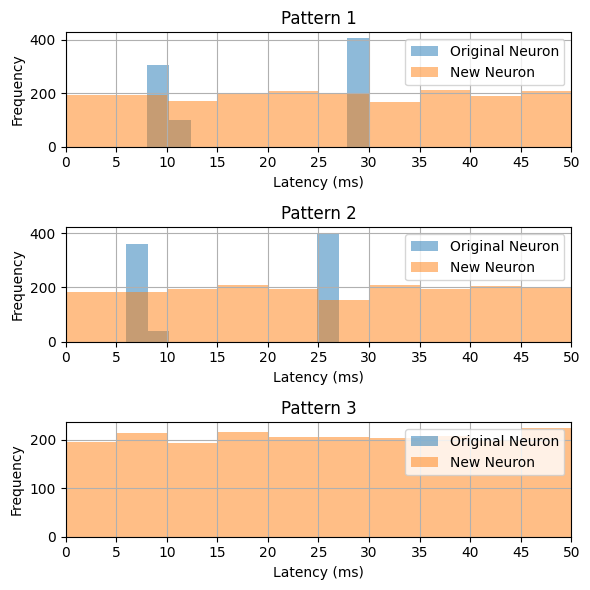

In [8]:
result = get_latency_results(N, monitor, position_copypaste_added, patternlength=0.050)

plot_new_pattern_hist(P, result, display, result_dir, image_name)

In [10]:
investigate_potential(monitor=monitor, dt=dt, position_copypaste=position_copypaste_added)